# 任务2_1 图神经网络
 本任务要求你使用图神经网络（Graph Neural Networks, GNNs）来处理图结构数据。你将学习如何构建和训练一个简单的图神经网络模型，以解决图分类或节点分类等任务。     
 使用的数据集为Cora数据集，这是一个常用的图神经网络数据集，包含了2708个科学出版物的引用关系和分类标签。

## 1）导入相关依赖

In [12]:
# 导入操作系统相关的库，用于处理文件路径和系统环境
import os
# 导入 PyTorch 深度学习框架库，用以构建张量和神经网络基础

# 允许 OpenMP 库重复加载，解决绘图时的 Kernel 崩溃问题
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
# 导入 PyTorch 的神经网络层模块（包含如线性层、损失函数等）
import torch.nn as nn
# 导入 PyTorch 神经网络自带函数模块（如激活函数 ReLU 等）
import torch.nn.functional as F
# 导入 NumPy 用于常规的科学计算和多维数组操作
import numpy as np
# 导入 Matplotlib 用于训练过程可视化
import matplotlib.pyplot as plt

# 导入 PyG（PyTorch Geometric）图结构信息存储的 Data 数据类型
from torch_geometric.data import Data
# 导入图结构相关的工具类：用于将有向图转换为无向图
from torch_geometric.utils import to_undirected
# 导入图卷积层（包含标准的GCN模型卷积计算算法）
from torch_geometric.nn import GCNConv

# 打印 PyTorch 版本，确认环境处于可用状态
print("torch version:", torch.__version__)

torch version: 2.8.0+cpu


## 2）加载Cora数据集

In [13]:
# 组合获取本任务所需的节点内容文件和引用边信息文件的本地绝对路径
content_path = os.path.join(os.getcwd(), 'cora', 'cora.content')
cites_path = os.path.join(os.getcwd(), 'cora', 'cora.cites')

# 1. 加载节点特征和标签
print(f"正在解析节点特征和标签{content_path}...")
# 使用 numpy 读取 cora 节点信息文件内全部数据结构信息至 numpy 数组（采用纯文本字符串）
contenet_data = np.genfromtxt(content_path, dtype=np.dtype(str))
# 赋予每篇论文一个纯数字的整型索引，建立字符串 ID 到数组下标的快速搜索字典
id_map = {id_str: idx for idx, id_str in enumerate(contenet_data[:, 0])}
# 将所有图节点最初的字符 ID 单独提取保存
node_ids = contenet_data[:, 0]

# 忽略第一列 ID 与最后一列分类标签，将其余的单词矩阵转化为标准的 32 位浮点张量，作为所有节点初始特征图
features = torch.tensor(contenet_data[:, 1:-1].astype(np.float32))

# 单独提取数组最后一列，保存为标签列
labels_str = contenet_data[:, -1]
# 为论文分类标签构建映射，将例如“Neural_Networks”等分类标记转换为不同的整型下标（如：0, 1）
classes = {label: i for i, label in enumerate(np.unique(labels_str))}
# 根据以上类别映射信息把节点所有分类文字信息更换为 PyTorch 可用于损失计算的包含长整形整数标签向量
labels = torch.tensor([classes[label] for label in labels_str], dtype=torch.long)

# 2. 加载边信息 (cora.cites)
print(f"正在解析边信息 {cites_path}...")
# 读取并存放网络间边连接引用的信息（数据按列包含着源论文 ID 和目标引用论文 ID）
cites_data = np.genfromtxt(cites_path, dtype=np.dtype(str))

# 根据之前确立的编号体系（id_map），将图边界点的绝对论文 ID 转换成系统可操作的连续索引整数对
edges = np.array([[id_map[edge[0]], id_map[edge[1]]] for edge in cites_data])

# 将维度转换为标准的格式：[源节点编号list, 目标节点编号list]，且需保障数据于内存中的连贯性
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# 由于节点之间具有无向关系时更利于基础GCN分析，此处直接把所有的边镜像添加反向边，形成不区分引用的双向无向图矩阵
edge_index = to_undirected(edge_index)

# 3. 划分数据集掩码 (Train/Test Mask)
# 计算参与训练、评估的总计图节点数
num_nodes = features.shape[0]
# 获得所有的图节点随机乱序排布号序列
indices = np.random.permutation(num_nodes)
# 从随机序列中选出前 140 号位置设为用于参与正向循环的训练集，抽取最后 1000 个位置设为测试集部分
train_idx, test_idx = indices[:140], indices[-1000:]

# 生成长度为总节点数量的掩模张量并在默认初始化时给它们赋予布尔False（用来表示是否可用来训练模型）
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
# 对应属于训练序列部分节点的下标设定成 True 掩模板
train_mask[train_idx] = True
# 为最终评估保留的类似掩模，所有默认布尔初值为 False
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
# 根据抽取序列为用作检测用节点开启 True 
test_mask[test_idx] = True

# 4. 构建 PyG 的 Data 对象
# 给特征数组（x），图关系矩阵数组（edge_index）和分类标签数组（y）联合填充到一个 PyG 数据类型内用于流转计算
data = Data(x=features, edge_index=edge_index, y=labels)
# 挂载额外属性存放训练以及验证集合节点标记状态，避免重新传参
data.train_mask = train_mask
data.test_mask = test_mask

# 获得实际有效的词汇数据（如 1433）的宽度
num_node_features = data.num_node_features
# 检测共出现多少实际有效的标签类别总数
num_classes = len(classes)

print(f"\n数据加载完成！")
print(f"节点特征维度: {num_node_features}, 类别数: {num_classes}")

正在解析节点特征和标签d:\CZ_WorkSpace\ai学习\深度学习实践\task2\task2_1\cora\cora.content...
正在解析边信息 d:\CZ_WorkSpace\ai学习\深度学习实践\task2\task2_1\cora\cora.cites...

数据加载完成！
节点特征维度: 1433, 类别数: 7


## 3）构建图神经网络模型GCNConv

In [14]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        # 继承和调用PyTorch内部神经网络组件的基础配置流程
        super(GCN, self).__init__()
        # 第一层图卷积层：负责提取基本图的信息聚集。输入即论文本身的 1433 维特征量，最终转换为我们定义的降维隐藏特征量。
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # 第二层图卷积层：在隐藏中间态（例如 16 维）特征提取上，再经过第二遍图内聚类转换出直接对应目标每个分类的分值序列。
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        # 在正向运算时获取传入的所有节点本身数据以及图网络的关系布局数组。
        x, edge_index = data.x, data.edge_index

        # 调用我们先于 __init__ 中搭建的第一个层完成初聚拢特征
        x = self.conv1(x, edge_index)
        # 激活层：引用极常用的ReLU滤除结果中所有的负成分输出
        x = F.relu(x)
        # 第二层次的卷积运算
        x = self.conv2(x, edge_index)
        # 通过 log 对数分类处理机制把任意权重的向量进行规范收缩成为可判知比率分布结果并供损失运算进行判断 (在类别这一维度也就是 dim=1 计算)。
        return F.log_softmax(x, dim=1)

## 4) 初始化模型和优化器

In [15]:
# 填入提取到参数信息以真正配置我们用于运行的图神经网络。在此设置其具备隐藏层特征维数为 16。
model = GCN(in_channels=num_node_features, hidden_channels=16, out_channels=num_classes)
# 指定深度学习的神经反向误差计算优化器 Adam ，指定默认学习修正步辐（lr: 0.01），此外使用 weight_decay 为 L2 正则权值衰减降低过拟合并稳定收敛能力。
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
# 选择交叉熵用来求取各类别实际结果和拟合结论损失比，从而对神经网络内计算链路节点权值施行奖惩，修正学习模型（注意该方法和内部计算已组合 LogSoftmax 其实略有冲突冗余由于这是 PyTorch 要求习惯直接传标签即可）。
criterion = nn.CrossEntropyLoss()

## 5) 训练与评估模型

Epoch: 020, Loss: 0.1595, Test Accuracy: 0.8000
Epoch: 040, Loss: 0.0149, Test Accuracy: 0.8040
Epoch: 060, Loss: 0.0135, Test Accuracy: 0.8120
Epoch: 080, Loss: 0.0158, Test Accuracy: 0.8150
Epoch: 100, Loss: 0.0142, Test Accuracy: 0.8150
Epoch: 120, Loss: 0.0125, Test Accuracy: 0.8180
Epoch: 140, Loss: 0.0115, Test Accuracy: 0.8180
Epoch: 160, Loss: 0.0107, Test Accuracy: 0.8240
Epoch: 180, Loss: 0.0100, Test Accuracy: 0.8200
Epoch: 200, Loss: 0.0095, Test Accuracy: 0.8200


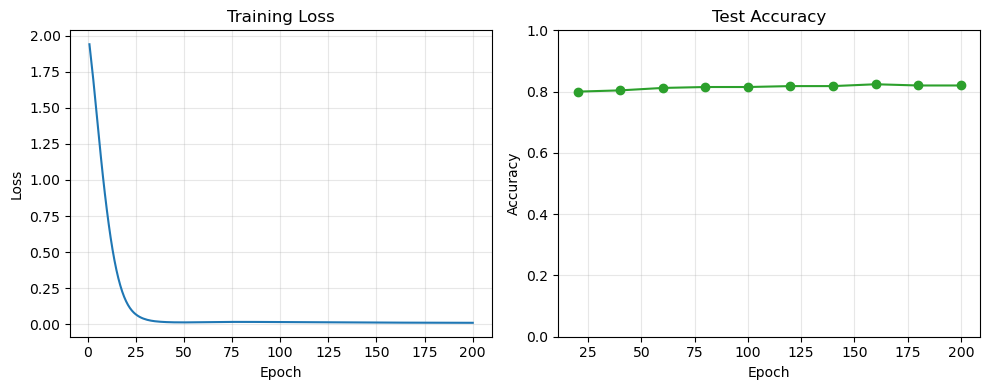

In [16]:
def train():
    # 宣告启动网络训练能力，激活所有层例如 Dropout, BatchNorm 等可能使用到的一些额外变量。
    model.train()
    # 开始每个周期的训练时将过去残留在变量里的所有算术误差清空防止误重迭计算方向。
    optimizer.zero_grad()
    # 提供目前所有顶点初始数据跟图连接配置去完成一次整个网图的前向信息预估推算。
    out = model(data)
    # 利用预先遮盖提取数组 (train_mask) 抽出本次用来练习训练部分的点推算信息然后求其交叉熵惩罚。
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    # 将模型所得亏损逆向遍历网络以累算出各个层数内对应修正梯度变量
    loss.backward()
    # 发送步骤推行命令要求 Adam 更新层节点变量数值来尝试寻找更小的 Loss 配置
    optimizer.step()
    # 将结果转化至基本 Python 数据内用于对外记录数值展示。
    return loss.item()


def test():
    # 关闭对图权重进行随机微调并使得预推求趋于明确确切。告知框架本流程意在评估而不是再学了。
    model.eval()
    # 使用训练完后的框架前向跑出结果。
    out = model(data)
    # 对预测分类比里抽取出占据权重最大的维度标记为其确诊判定的目标分类项类别号。
    pred = out.argmax(dim=1)  # 获取每个节点预测出最大可能性的类别
    # 只提取掩膜内的数据来与现实标签进行相等分析并且最终合计数。
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()  # 计算测试集掩码内预测成功的全数目总数 
    # 在正确的全数目基础上求总长除式来反馈实际该模式在没有预先透露答案下的总体预言确准度率。
    acc = correct / data.test_mask.sum().item()
    return acc

# 记录训练过程指标
loss_history = []
acc_history = []
acc_epochs = []

# 定义该 AI 要用所有的样本执行一共 200 次轮询遍历计算练习。
for epoch in range(200):
    # 进行内部训练周期一次并且抽取返回这期间内的计算不确定丢失亏损。
    loss = train()
    loss_history.append(loss)
    # 由于频每 Epoch 输出会有很高占幅，每走过整除这 20 倍数轮番进行一次评判测试以展示进步量。
    if (epoch + 1) % 20 == 0:
        # 获取当下状态中模型测算出正确的百分比。
        acc = test()
        acc_history.append(acc)
        acc_epochs.append(epoch + 1)
        # 清晰化呈现控制台输出用于掌握训练的进度。
        print(f'Epoch: {epoch + 1:03d}, Loss: {loss:.4f}, Test Accuracy: {acc:.4f}')

# 训练过程与结果可视化
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(range(1, len(loss_history) + 1), loss_history, color="tab:blue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(acc_epochs, acc_history, marker="o", color="tab:green")
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()